In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("/content/defects_data.csv")

In [ ]:
df

,defect_id,product_id,defect_type,defect_date,defect_location,severity,inspection_method,repair_cost
0,1,15,Structural,6/6/2024,Component,Minor,Visual Inspection,245.47
1,2,6,Functional,4/26/2024,Component,Minor,Visual Inspection,26.87
2,3,84,Structural,2/15/2024,Internal,Minor,Automated Testing,835.81
3,4,10,Functional,3/28/2024,Internal,Critical,Automated Testing,444.47
4,5,14,Cosmetic,4/26/2024,Component,Minor,Manual Testing,823.64
...,...,...,...,...,...,...,...,...
995,996,25,Structural,3/1/2024,Component,Minor,Automated Testing,813.14
996,997,23,Functional,3/21/2024,Component,Moderate,Automated Testing,944.07
997,998,17,Structural,1/16/2024,Component,Minor,Automated Testing,401.12
998,999,96,Cosmetic,6/21/2024,Internal,Moderate,Manual Testing,775.63


In [ ]:
df.shape

(1000, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   defect_id          1000 non-null   int64  
 1   product_id         1000 non-null   int64  
 2   defect_type        1000 non-null   object 
 3   defect_date        1000 non-null   object 
 4   defect_location    1000 non-null   object 
 5   severity           1000 non-null   object 
 6   inspection_method  1000 non-null   object 
 7   repair_cost        1000 non-null   float64
dtypes: float64(1), int64(2), object(5)
memory usage: 62.6+ KB


In [ ]:
df['defect_type'].unique()

array(['Structural', 'Functional', 'Cosmetic'], dtype=object)

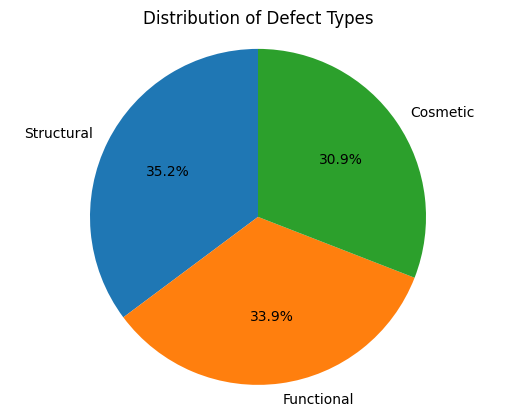

In [ ]:
import matplotlib.pyplot as plt

# The columns 'Item Fat Content' and 'Sales' do not exist in the DataFrame.
# We will plot the distribution of 'defect_type' instead.
defect_type_counts = df['defect_type'].value_counts()

plt.pie(
    defect_type_counts,
    labels=defect_type_counts.index,
    autopct='%.1f%%',
    startangle=90
)
plt.title('Distribution of Defect Types')
plt.axis('equal')  # Ensures pie chart is a circle
plt.show()

In [ ]:
value_counts = defect_type_counts.sum()
print(f"Total defects: ${value_counts:,.0f}")

Total defects: $1,000


In [ ]:
#Average value count
avg_value_count = defect_type_counts.mean()
print(f"Average defects: ${avg_value_count:,.0f}")

Average defects: $333


In [ ]:
no_of_items_sold = df['defect_id'].count()
print(f"Number of items sold: {no_of_items_sold:,.0f}")

Number of items sold: 1,000


In [ ]:
avg_repair_cost = df['repair_cost'].mean()
print(f"Average repair cost: {avg_repair_cost:.2f}")

Average repair cost: 507.63


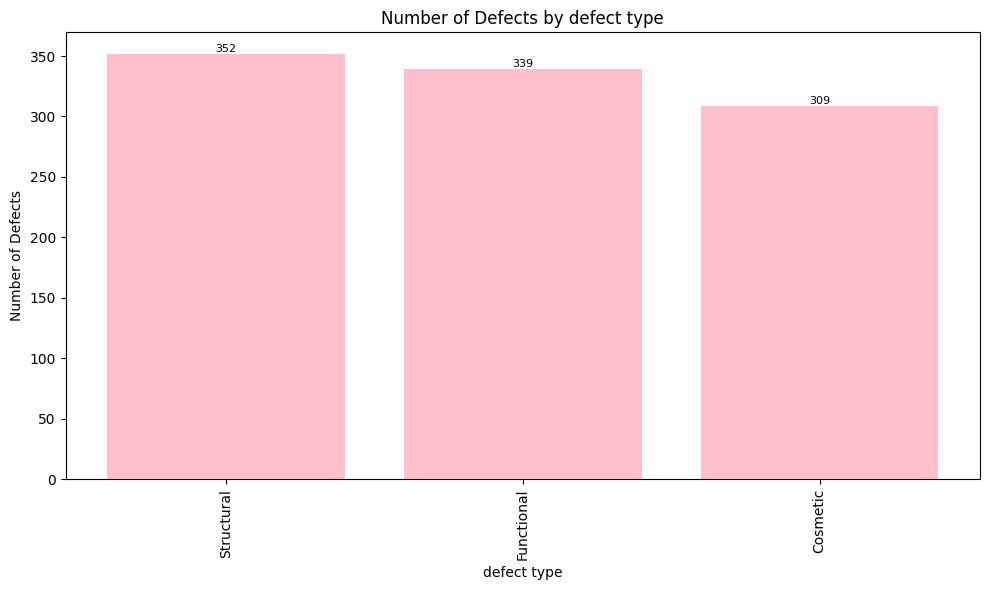

In [ ]:
sales_by_type = df['defect_type'].value_counts().sort_values(ascending=False)

# Set figure size
plt.figure(figsize=(10, 6))

# Create bar chart
bars = plt.bar(sales_by_type.index, sales_by_type.values, color='pink')

# Rotate x-axis labels for readability
plt.xticks(rotation=90)
plt.xlabel('defect type')
plt.ylabel('Number of Defects')
plt.title('Number of Defects by defect type')
# Add value labels on top of each bar
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{bar.get_height():,.0f}',
        ha='center',
        va='bottom',
        fontsize=8
    )

# Adjust layout to prevent clipping
plt.tight_layout()
plt.show()

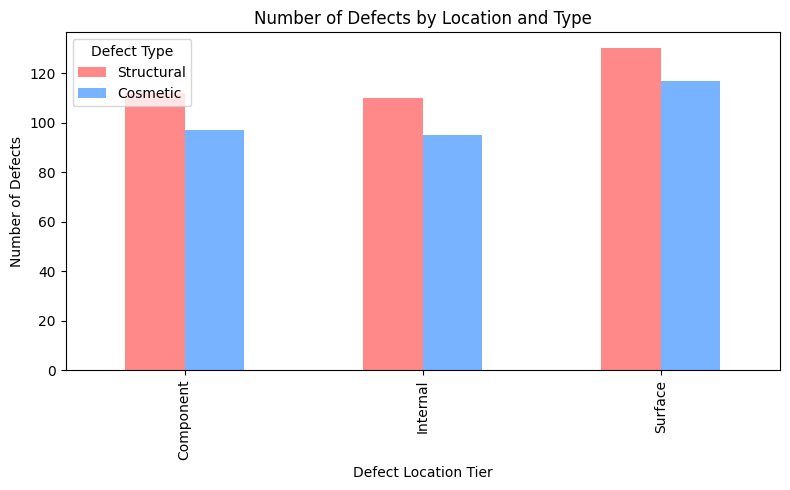

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Group and reshape the data by counting occurrences
grouped = df.groupby(['defect_location', 'defect_type']).size().unstack(fill_value=0)

# Filter only 'Structural' and 'Cosmetic' categories (corrected from 'structured')
grouped = grouped[['Structural', 'Cosmetic']]

# Plot the grouped bar chart
ax = grouped.plot(
    kind='bar',
    figsize=(8, 5),
    title='Number of Defects by Location and Type',
    xlabel='Defect Location',
    ylabel='Number of Defects',
    color=['#Ff8888', '#77B3FF']  # Optional: custom colors
)

# Axis labels and legend
plt.xlabel('Defect Location Tier')
plt.ylabel('Number of Defects')
plt.legend(title='Defect Type')

# Layout adjustment
plt.tight_layout()
plt.show()

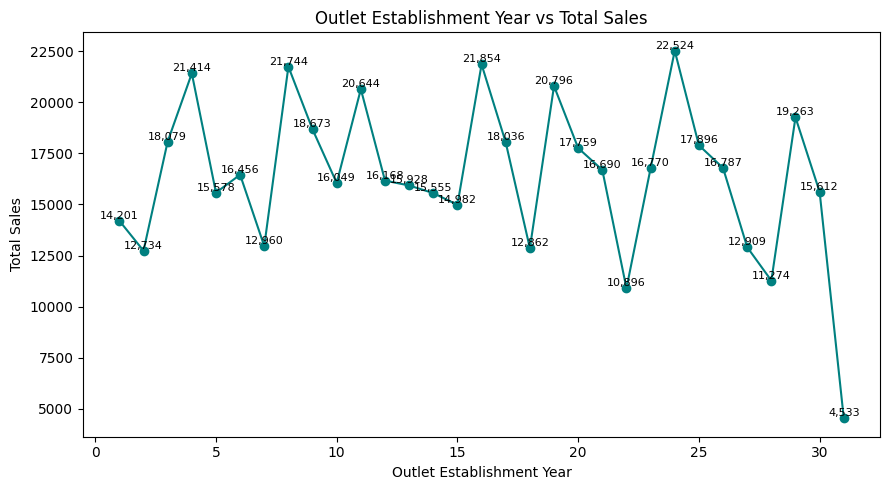

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert 'defect_date' to datetime objects
df['defect_date'] = pd.to_datetime(df['defect_date'])

# Group by defect year and sum repair cost
repair_cost_by_year = df.groupby(df['defect_date'].dt.day)['repair_cost'].sum().sort_index()

plt.figure(figsize=(9, 5))
plt.plot(repair_cost_by_year.index, repair_cost_by_year.values, marker='o', linestyle='-', color='teal')
plt.xlabel('Outlet Establishment Year')
plt.ylabel('Total Sales')
plt.title('Outlet Establishment Year vs Total Sales')

# Add value labels
for x, y in zip(repair_cost_by_year.index, repair_cost_by_year.values):
    plt.text(x, y, f'{y:,.0f}', ha='center', va='bottom', fontsize=8)


plt.tight_layout()
plt.show()

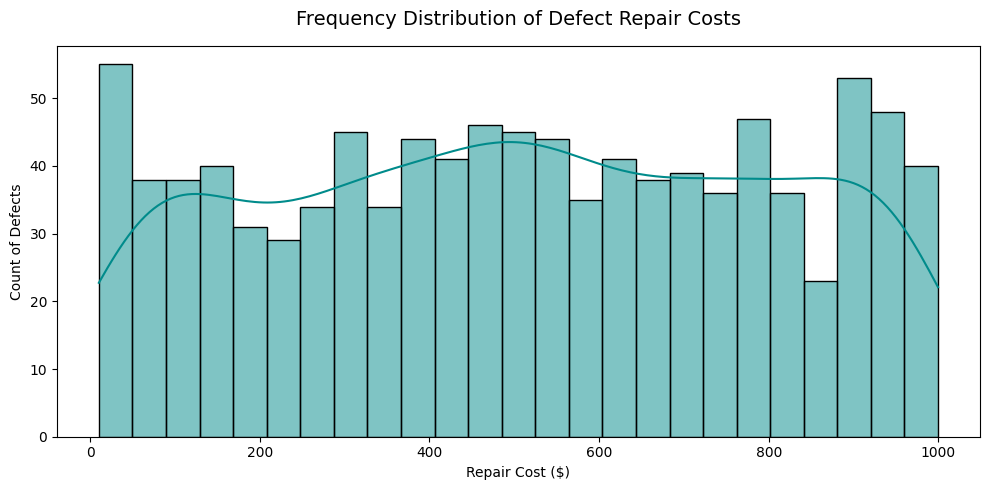

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='repair_cost', bins=25, kde=True, color='darkcyan')
plt.title('Frequency Distribution of Defect Repair Costs', fontsize=14, pad=15)
plt.xlabel('Repair Cost ($)')
plt.ylabel('Count of Defects')
plt.tight_layout()
plt.show()


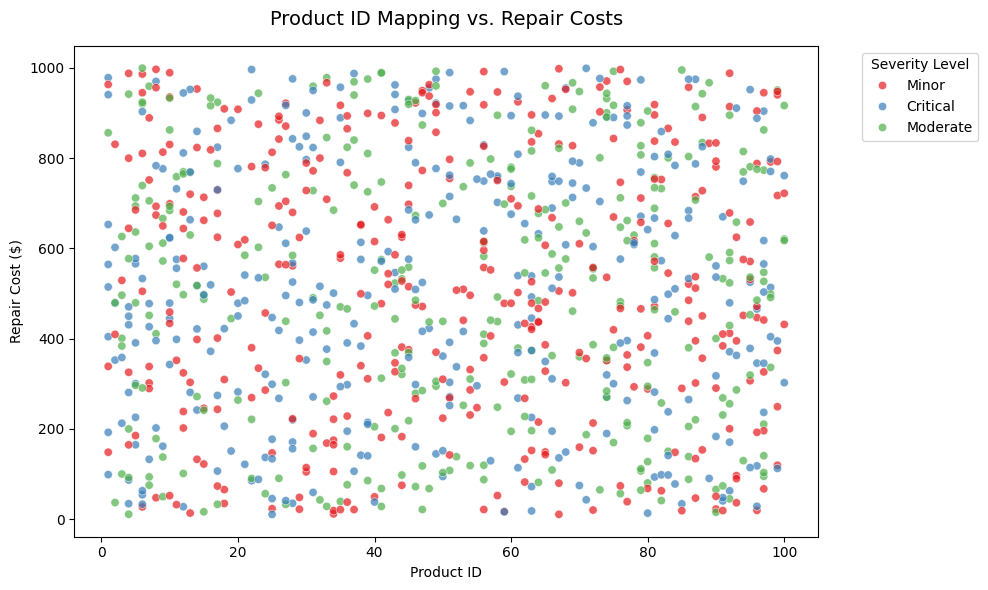

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# Evaluates if repair costs trend higher for specific sequential product ID batches
sns.scatterplot(data=df, x='product_id', y='repair_cost', hue='severity', palette='Set1', alpha=0.7)
plt.title('Product ID Mapping vs. Repair Costs', fontsize=14, pad=15)
plt.xlabel('Product ID')
plt.ylabel('Repair Cost ($)')
plt.legend(title='Severity Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


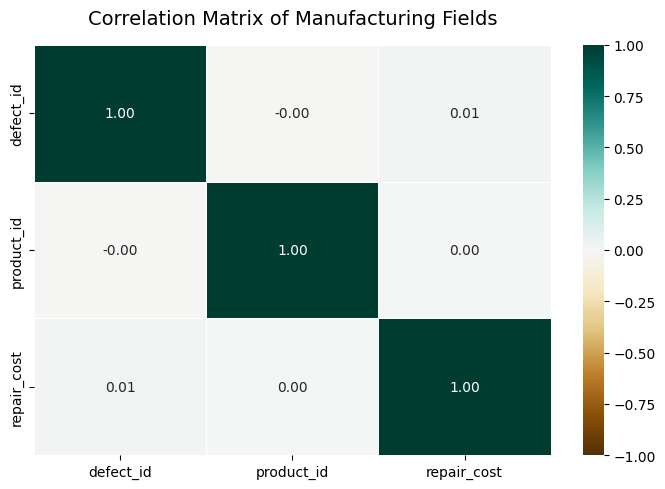

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
# Compute correlation between available numeric variables
numeric_cols = df[['defect_id', 'product_id', 'repair_cost']]
sns.heatmap(numeric_cols.corr(), annot=True, cmap='BrBG', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix of Manufacturing Fields', fontsize=14, pad=15)
plt.tight_layout()
plt.show()


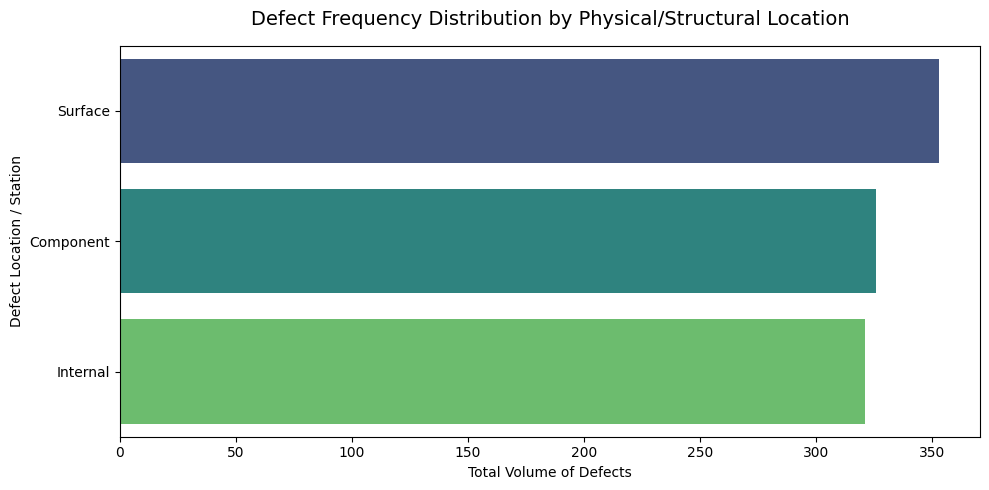

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
# Captures structural factory zones or region counts when exact GPS values are absent
location_volumes = df['defect_location'].value_counts()

sns.barplot(x=location_volumes.values, y=location_volumes.index, hue=location_volumes.index, legend=False, palette='viridis')
plt.title('Defect Frequency Distribution by Physical/Structural Location', fontsize=14, pad=15)
plt.xlabel('Total Volume of Defects')
plt.ylabel('Defect Location / Station')
plt.tight_layout()
plt.show()


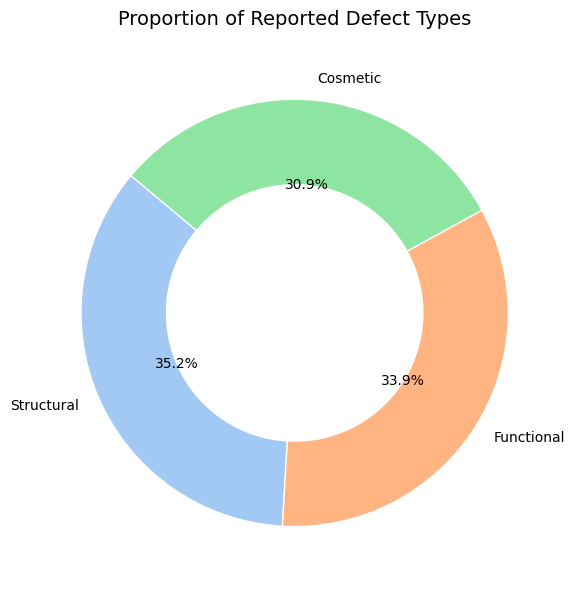

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 6))
defect_counts = df['defect_type'].value_counts()

# The width parameter creates a central hole, changing a standard pie chart into a clean donut chart
plt.pie(defect_counts, labels=defect_counts.index, autopct='%1.1f%%', startangle=140,
        colors=sns.color_palette('pastel'), wedgeprops=dict(width=0.4, edgecolor='w'))

plt.title('Proportion of Reported Defect Types', fontsize=14, pad=15)
plt.tight_layout()
plt.show()


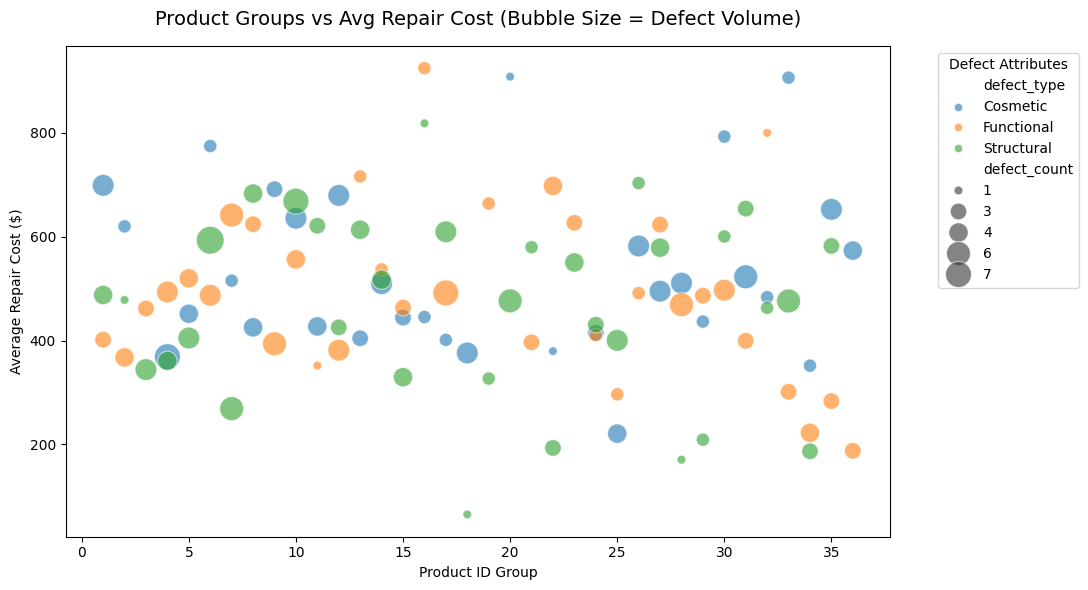

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(11, 6))
# Aggregating metrics slightly ensures clear, readable bubble separations
bubble_data = df.groupby(['product_id', 'defect_type']).agg(
    avg_cost=('repair_cost', 'mean'),
    defect_count=('defect_id', 'count')
).reset_index().head(100) # Displays the first 100 clusters to prevent visual crowding

sns.scatterplot(data=bubble_data, x='product_id', y='avg_cost', size='defect_count',
                sizes=(40, 400), alpha=0.6, hue='defect_type', palette='tab10')

plt.title('Product Groups vs Avg Repair Cost (Bubble Size = Defect Volume)', fontsize=14, pad=15)
plt.xlabel('Product ID Group')
plt.ylabel('Average Repair Cost ($)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Defect Attributes')
plt.tight_layout()
plt.show()


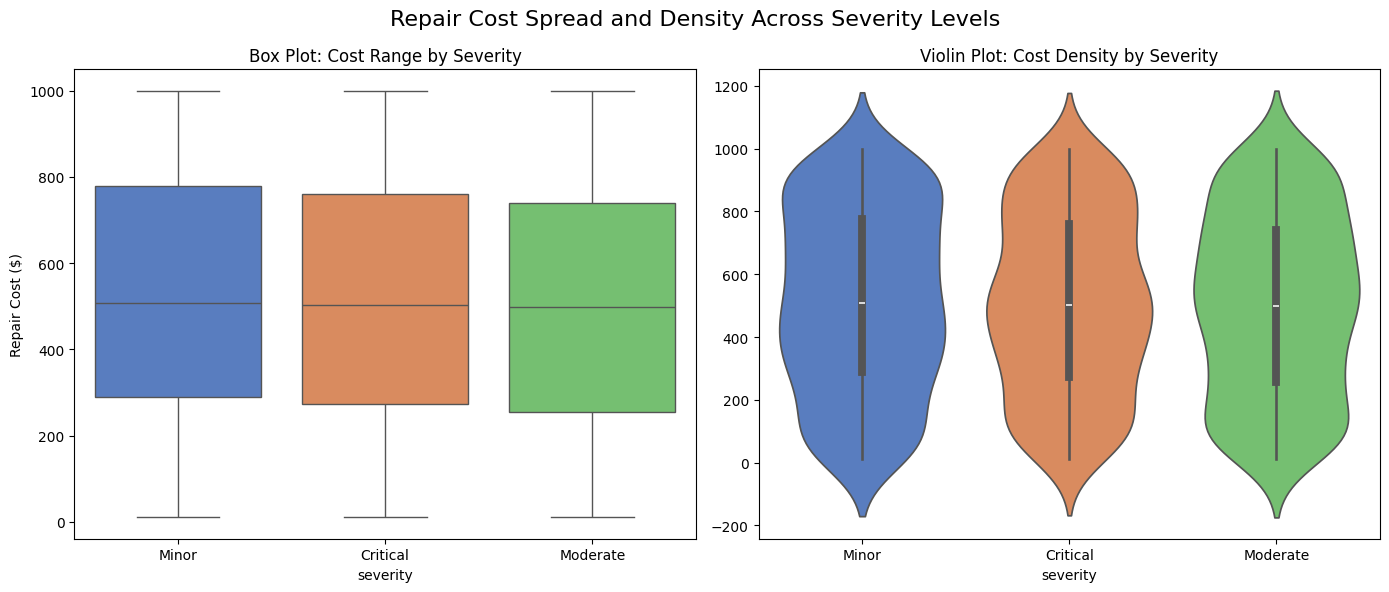

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Box Plot component
sns.boxplot(data=df, x='severity', y='repair_cost', ax=axes[0], palette='muted', hue='severity', legend=False)
axes[0].set_title('Box Plot: Cost Range by Severity')
axes[0].set_ylabel('Repair Cost ($)')

# Violin Plot component
sns.violinplot(data=df, x='severity', y='repair_cost', ax=axes[1], palette='muted', hue='severity', legend=False)
axes[1].set_title('Violin Plot: Cost Density by Severity')
axes[1].set_ylabel('') # Clear redundant label

plt.suptitle('Repair Cost Spread and Density Across Severity Levels', fontsize=16)
plt.tight_layout()
plt.show()
